- This problem occurs when on updating the weights during gradient descent, there is almost no change in weights and thus almost no decrease in Loss. THis happens because back propagation deals with multiplication of multiple gradients terms, now when we multiply the terms which are already small in number, the result is even smaller, and thus when we subtract this gradient*lr to get the new weight, there is vanishingly small change in the weights.

### To recognize this problem, we can see that after every epoch, if the Loss decrease is stagnant or has stopped, this is generally the sign of VGP

In [1]:
# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense

In [2]:
X,y = make_moons(n_samples = 1000 , noise = 0.05 , random_state= 42 )

In [4]:
X

array([[-0.02137124,  0.40618608],
       [ 0.97670045, -0.45832306],
       [ 0.90405882, -0.37651952],
       ...,
       [ 1.66258462, -0.3079193 ],
       [-0.94355873,  0.3278936 ],
       [ 0.79419406,  0.60777171]], shape=(1000, 2))

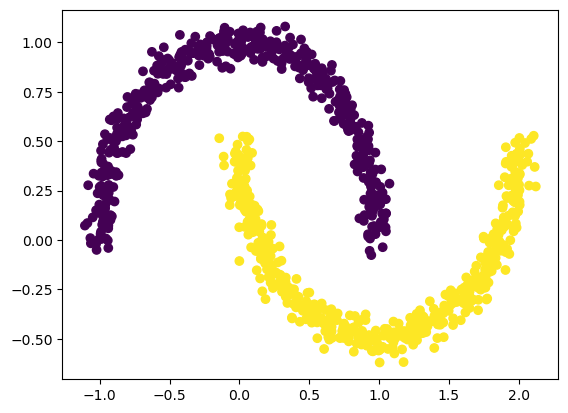

In [9]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0] , X[:,1] , c=y , cmap='viridis')
plt.show()

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [11]:
# building the Neural Network
model = Sequential()

model.add(Dense(10 , activation='sigmoid' , input_dim = 2))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))


c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,141 (4.46 KB)

 Trainable params: 1,141 (4.46 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(loss='binary_crossentropy' , optimizer='Adam', metrics = ['accuracy'])

In [15]:
old_weights = model.get_weights()[0]

In [58]:
model.fit(X_train,y_train , epochs = 18) # trained for one time

Epoch 1/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5000 - loss: 0.6932
Epoch 2/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4725 - loss: 0.6933
Epoch 3/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4775 - loss: 0.6937
Epoch 4/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4975 - loss: 0.6933
Epoch 5/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 0.6935
Epoch 6/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4725 - loss: 0.6937
Epoch 7/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5000 - loss: 0.6932
Epoch 8/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 0.6933
Epoch 9/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5000 - loss: 0.6937
Epoch 10/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4925 - loss: 0.6935
Epoch 11/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4825 - loss: 0.6941
Epoch 12/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4875 - lo

In [24]:
# after training my weights must have changed
new_weights = model.get_weights()[0]

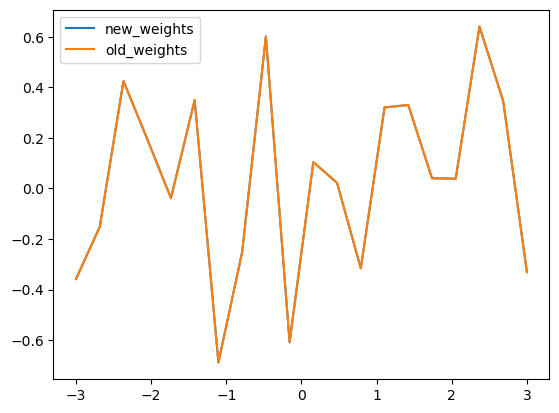

In [28]:
x_random = np.linspace(-3,3,20)
plt.plot(x_random , new_weights.flatten() , label='new_weights')
plt.plot(x_random , old_weights.flatten() , label='old_weights')
plt.legend()
plt.show()

- Can you interpret this? The new weights are almost identical with the old weights, this shows that there was close to none change after we did gradient descent for one loop

- Numerically we can see this using the values of gradients we got, and the percent change in the weights

In [32]:
lr = model.optimizer.get_config()['learning_rate'] # this gives the learning rate my optimizer is using
gradients = (old_weights - new_weights)/lr
percent_change = abs((new_weights - old_weights)/old_weights)*100

In [33]:
gradients

array([[-0.21597742, -0.6213933 , -0.02673268,  0.16801058,  0.00261515,
        -0.23475288,  0.00494719, -0.19067524,  0.5732775 ,  0.4355907 ],
       [ 0.12376159,  0.33999047,  0.01272559, -0.08913874, -0.0012219 ,
         0.1351051 , -0.00209734,  0.10263919, -0.35625693, -0.2733171 ]],
      dtype=float32)

- These are small values 

In [34]:
percent_change

array([[6.02743588e-02, 4.08074319e-01, 6.29713852e-03, 8.58588889e-02,
        6.84724143e-03, 6.71781078e-02, 7.18962052e-04, 7.55695254e-02,
        9.53544080e-02, 7.16197044e-02],
       [1.18849464e-01, 1.51904595e+00, 4.02520876e-03, 2.78493650e-02,
        3.70118069e-04, 3.34247231e-01, 5.44882845e-03, 1.60287004e-02,
        1.03287026e-01, 8.24957192e-02]], dtype=float32)

- already the change we see are very close to 0

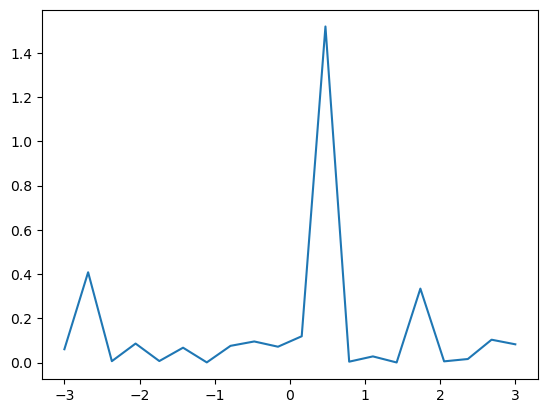

In [37]:
plt.plot(x_random , percent_change.flatten())

### Tackle Vanishing Gradient Problem

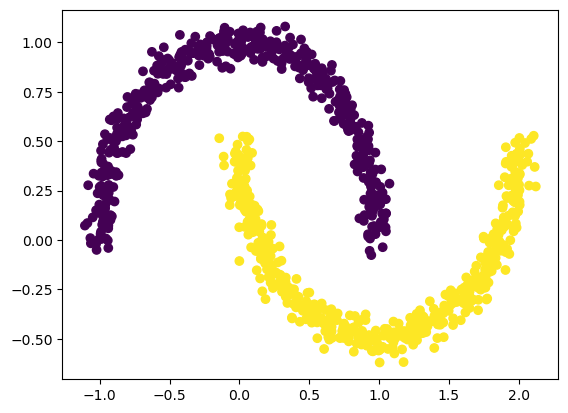

c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5000 - loss: 0.8438
Epoch 2/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 0.7865
Epoch 3/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 0.7488 
Epoch 4/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 0.7231 
Epoch 5/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 0.7094
Epoch 6/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 0.6990
Epoch 7/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 0.6923 
Epoch 8/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 0.6872 
Epoch 9/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5775 - loss: 0.6827 
Epoch 10/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7262 - loss: 0.6779 
Epoch 11/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7362 - loss: 0.6731
Epoch 12/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.742

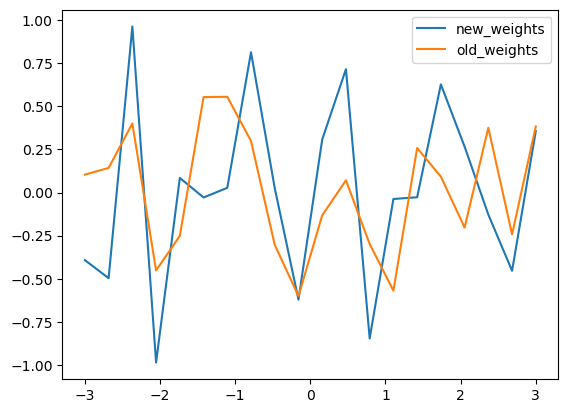

In [59]:
# 1. Reduce the complexity of the Neural Network
X,y = make_moons(n_samples = 1000 , noise = 0.05 , random_state= 42 )
import matplotlib.pyplot as plt
plt.scatter(X[:,0] , X[:,1] , c=y , cmap='viridis')
plt.show()
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
# building the Neural Network
model = Sequential()

model.add(Dense(10 , activation='sigmoid' , input_dim = 2))
model.add(Dense(10,activation='sigmoid'))
# model.add(Dense(10,activation='sigmoid'))
# model.add(Dense(10,activation='sigmoid'))
# model.add(Dense(10,activation='sigmoid'))
# model.add(Dense(10,activation='sigmoid'))
# model.add(Dense(10,activation='sigmoid'))
# model.add(Dense(10,activation='sigmoid'))
# model.add(Dense(10,activation='sigmoid'))
# model.add(Dense(10,activation='sigmoid'))
# model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy' , optimizer='Adam', metrics = ['accuracy'])
old_weights = model.get_weights()[0]
model.fit(X_train,y_train , epochs = 18) # trained for one time
# after training my weights must have changed
new_weights = model.get_weights()[0]
x_random = np.linspace(-3,3,20)
plt.plot(x_random , new_weights.flatten() , label='new_weights')
plt.plot(x_random , old_weights.flatten() , label='old_weights')
plt.legend()
plt.show()

- We see that the loss is not stagnant now, it is reducing after each epoch.
- Although this is not the proper solution, since we cannot reduce the complexity of our NN as we need it to learn complex relations between the data

### 2. Using ReLU activation Function instead of sigmoid

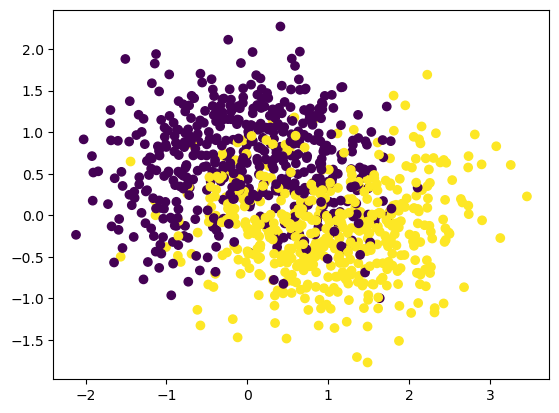

c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6825 - loss: 0.6888
Epoch 2/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7725 - loss: 0.6732
Epoch 3/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8037 - loss: 0.6325
Epoch 4/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8150 - loss: 0.5407
Epoch 5/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8125 - loss: 0.4540
Epoch 6/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8150 - loss: 0.4336
Epoch 7/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8100 - loss: 0.4419
Epoch 8/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8200 - loss: 0.4271
Epoch 9/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8138 - loss: 0.4181
Epoch 10/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8163 - loss: 0.4239
Epoch 11/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8275 - loss: 0.4133
Epoch 12/18
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8250 - lo

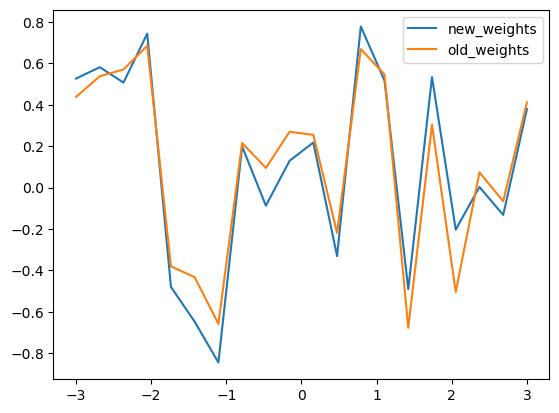

In [68]:
# 1. Reduce the complexity of the Neural Network
X,y = make_moons(n_samples = 1000 , noise = 0.5 , random_state= 42 )
import matplotlib.pyplot as plt
plt.scatter(X[:,0] , X[:,1] , c=y , cmap='viridis')
plt.show()
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
# building the Neural Network
model = Sequential()

model.add(Dense(10 , activation='relu' , input_dim = 2))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy' , optimizer='Adam', metrics = ['accuracy'])
old_weights = model.get_weights()[0]
model.fit(X_train,y_train , epochs = 18) # trained for one time
# after training my weights must have changed
new_weights = model.get_weights()[0]
x_random = np.linspace(-3,3,20)
plt.plot(x_random , new_weights.flatten() , label='new_weights')
plt.plot(x_random , old_weights.flatten() , label='old_weights')
plt.legend()
plt.show()

In [69]:
y_log = model.predict(X_test)

y_hat = np.where(y_log>0.5 , 1, 0)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [70]:
# accuracy
from sklearn.metrics import accuracy_score,precision_score,recall_score, confusion_matrix,classification_report
print(f'Accuracy Score-> {accuracy_score(y_test , y_hat)}')
print(f'Precision Score-> {precision_score(y_test , y_hat)}')
print(f'Recall Score-> {recall_score(y_test , y_hat)}')
print(f'Confusion MAtrix-> {confusion_matrix(y_test , y_hat)}')
print(f'Classification Repor-> {classification_report(y_test , y_hat)}')


Accuracy Score-> 0.79
Precision Score-> 0.8222222222222222
Recall Score-> 0.74
Confusion MAtrix-> [[84 16]
 [26 74]]
Classification Repor->               precision    recall  f1-score   support

           0       0.76      0.84      0.80       100
           1       0.82      0.74      0.78       100

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.79      0.79      0.79       200

